<a href="https://colab.research.google.com/github/Dass-19/LTSF/blob/main/LTSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import torch.nn as nn

In [37]:
%matplotlib inline

In [38]:
np.random.seed(67)

# Resumen del paper

# Dataset

In [44]:
ETTh1 = pd.read_csv("https://raw.githubusercontent.com/zhouhaoyi/ETDataset/refs/heads/main/ETT-small/ETTh1.csv")

In [45]:
ETTh1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB


In [46]:
ETTh1['date'] = pd.to_datetime(ETTh1['date'])

In [47]:
ETTh1.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [48]:
ETTh1.isnull().sum()

,0
date,0
HUFL,0
HULL,0
MUFL,0
MULL,0
LUFL,0
LULL,0
OT,0


In [49]:
ETTh1.describe()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,2017-06-28 21:30:00,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
min,2016-07-01 00:00:00,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,2016-12-29 10:45:00,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,2017-06-28 21:30:00,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,2017-12-27 08:15:00,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,2018-06-26 19:00:00,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000
std,NaN,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946


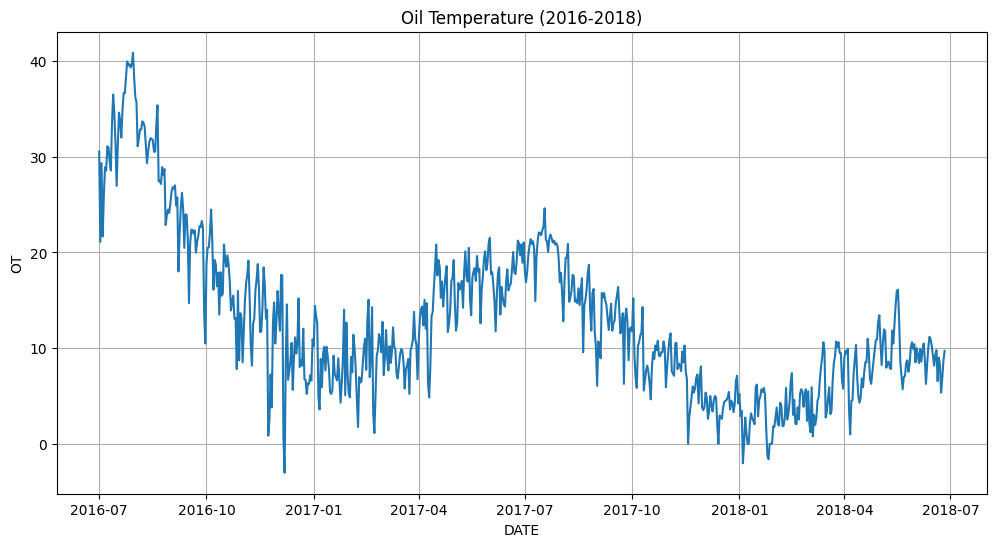

In [50]:
ETTh1.index = ETTh1.date
ETTh1 = ETTh1.asfreq('D')
plt.figure(figsize=(12, 6))
plt.plot(ETTh1.OT)
plt.title('Oil Temperature (2016-2018)')
plt.xlabel('DATE')
plt.ylabel('OT')
plt.grid()

- 96 pasos = 4 días de datos históricos
- 336 pasos = 14 días de datos históricos

In [51]:
ETTh1['OT_96'] = ETTh1['OT'].rolling(window=4).mean()
ETTh1['OT_336'] = ETTh1['OT'].rolling(window=14).mean()

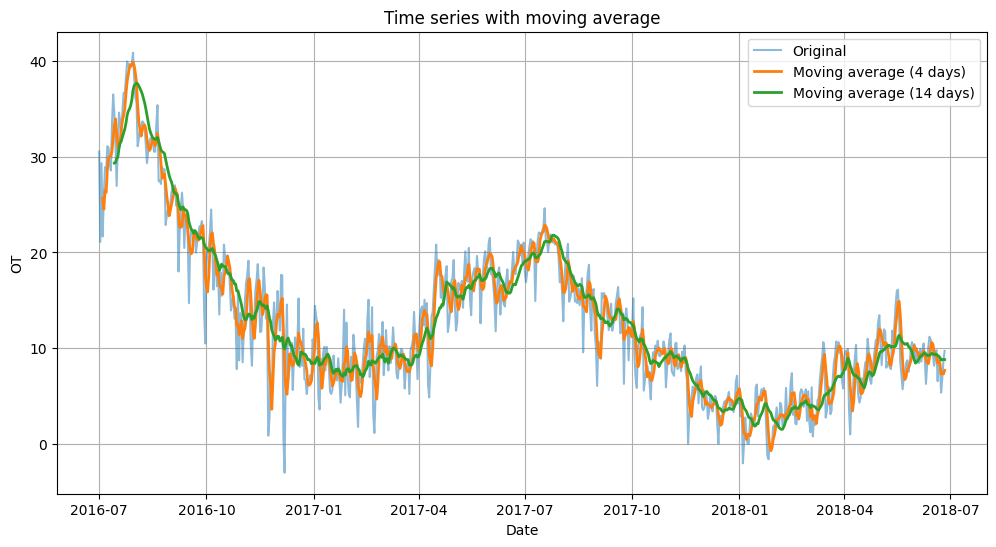

In [52]:
plt.figure(figsize=(12, 6))
plt.plot(ETTh1['OT'], label='Original', alpha=0.5)
plt.plot(ETTh1['OT_96'], label='Moving average (4 days)', linewidth=2)
plt.plot(ETTh1['OT_336'], label='Moving average (14 days)', linewidth=2)
plt.title('Time series with moving average')
plt.xlabel('Date')
plt.ylabel('OT')
plt.legend()
plt.grid()
plt.show()

# Implementación

# Entrenamiento y evaluación

 # Análisis crítico

# Conclusiones